## Cell 1 — Imports & Data Loading

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML
from datetime import datetime

data = pd.read_csv("construction_schedule_sample.csv")
data.columns = data.columns.str.strip()
data["Start"]    = pd.to_datetime(data["Start"], format="%m-%d-%Y", errors="coerce")
data["End"]      = pd.to_datetime(data["End"],   format="%m-%d-%Y", errors="coerce")
data["Progress"] = data["Progress"].str.replace("%", "", regex=False).astype(float)

today = pd.Timestamp(datetime.today().date())
data["Delay"] = (data["End"] < today) & (data["Progress"] < 100)

print("✅ Data loaded successfully!")
print(f"   Total tasks   : {len(data)}")
print(f"   Delayed tasks : {data['Delay'].sum()}")
print(f"   On-track tasks: {(~data['Delay']).sum()}")

✅ Data loaded successfully!
   Total tasks   : 15
   Delayed tasks : 0
   On-track tasks: 15


## Cell 2 — Dashboard Title & Overall Progress

In [2]:
overall_progress = data["Progress"].mean()

display(HTML(f"""
<div style="font-family:sans-serif; padding:20px; background:#f0f2f6; border-radius:12px; margin-bottom:16px;">
    <h1 style="color:#262730; margin:0 0 4px;">🏗️ Construction Progress Tracking Dashboard</h1>
    <p style="color:#555; margin:0;">Project Operation Data &nbsp;|&nbsp; Today: {today.strftime('%b %d, %Y')}</p>
</div>
"""))

display(HTML(f"""
<div style="font-family:sans-serif; display:inline-block; background:#fff;
            border-radius:10px; padding:20px 32px; box-shadow:0 2px 8px rgba(0,0,0,0.08); margin-bottom:20px;">
    <div style="font-size:13px; color:#888; margin-bottom:4px;">📊 Overall Project Progress</div>
    <div style="font-size:42px; font-weight:800; color:#262730;">{overall_progress:.2f}%</div>
    <div style="background:#e0e0e0; border-radius:20px; height:10px; margin-top:10px; width:300px;">
        <div style="background:{'#27ae60' if overall_progress>=75 else '#f0a500' if overall_progress>=40 else '#e74c3c'};
                    width:{overall_progress:.1f}%; height:10px; border-radius:20px;"></div>
    </div>
</div>
"""))

## Cell 3 — Delay Alert Notifications

In [3]:
delayed = data[data["Delay"] == True]

if not delayed.empty:
    alert_rows = ""
    for _, row in delayed.iterrows():
        alert_rows += f"""
        <div style="background:#fff8e1; border-left:4px solid #f0a500; border-radius:6px;
                    padding:10px 16px; margin-bottom:8px; font-size:14px; color:#7d5a00;">
            ⚠️ <b>{row['Operation']}</b> &nbsp;—&nbsp;
            Progress: <b>{row['Progress']:.0f}%</b> &nbsp;|&nbsp;
            Deadline: <b>{row['End'].strftime('%b %d, %Y')}</b>
        </div>"""

    display(HTML(f"""
    <div style="font-family:sans-serif; margin-bottom:20px;">
        <div style="background:#fde8e8; border-left:5px solid #e53e3e; border-radius:8px;
                    padding:14px 18px; margin-bottom:12px; font-weight:700;
                    color:#c0392b; font-size:15px;">
            🚨 DELAY ALERT — {len(delayed)} operations are behind schedule!
        </div>
        {alert_rows}
    </div>
    """))
else:
    display(HTML("""
    <div style="font-family:sans-serif; background:#e6f9f0; border-left:5px solid #27ae60;
                border-radius:8px; padding:14px 18px; font-weight:700;
                color:#1e7e45; font-size:15px; margin-bottom:20px;">
        ✅ All operations are on track!
    </div>
    """))

## Cell 4 — Data Table

In [4]:
display(HTML("<h3 style='font-family:sans-serif; color:#333; margin-bottom:10px;'>📋 Project Data Table</h3>"))

display_data = data.copy()
display_data["Start"]    = display_data["Start"].dt.strftime("%b %d, %Y")
display_data["End"]      = display_data["End"].dt.strftime("%b %d, %Y")
display_data["Progress"] = display_data["Progress"].apply(lambda x: f"{x:.0f}%")
display_data["Delay"]    = display_data["Delay"].apply(lambda x: "⚠️ Delayed" if x else "✅ On Track")

display(display_data.style
    .set_properties(**{"font-size": "13px", "text-align": "left"})
    .apply(lambda col: [
        "background-color: #fde8e8" if v == "⚠️ Delayed" else
        "background-color: #e6f9f0" if v == "✅ On Track" else ""
        for v in col], subset=["Delay"])
    .set_table_styles([
        {"selector": "thead th", "props": [("background-color", "#f7f8fa"),
                                            ("font-weight", "bold"),
                                            ("color", "#444"),
                                            ("padding", "10px")]},
        {"selector": "td", "props": [("padding", "8px 12px")]},
    ])
)

,S.No,Operation,Duration,Start,End,Progress,Delay
0,1,Site Survey and Soil Testing,4,"Mar 01, 2026","Mar 05, 2026",100%,✅ On Track
1,2,Design and Planning,6,"Mar 05, 2026","Mar 11, 2026",100%,✅ On Track
2,3,Site Clearance and Leveling,3,"Mar 11, 2026","Mar 14, 2026",100%,✅ On Track
3,4,Foundation Excavation,5,"Mar 14, 2026","Mar 19, 2026",90%,✅ On Track
4,5,Foundation Construction,8,"Mar 19, 2026","Mar 27, 2026",75%,✅ On Track
5,6,Plinth Beam and Column Work,6,"Mar 27, 2026","Apr 02, 2026",50%,✅ On Track
6,7,Superstructure and Slab Work,12,"Apr 02, 2026","Apr 14, 2026",30%,✅ On Track
7,8,Brick Masonry and Wall Construction,7,"Apr 14, 2026","Apr 21, 2026",10%,✅ On Track
8,9,Roofing and Waterproofing,5,"Apr 21, 2026","Apr 26, 2026",0%,✅ On Track
9,10,Door and Window Installation,4,"Apr 26, 2026","Apr 30, 2026",0%,✅ On Track


## Cell 5 — Gantt Chart

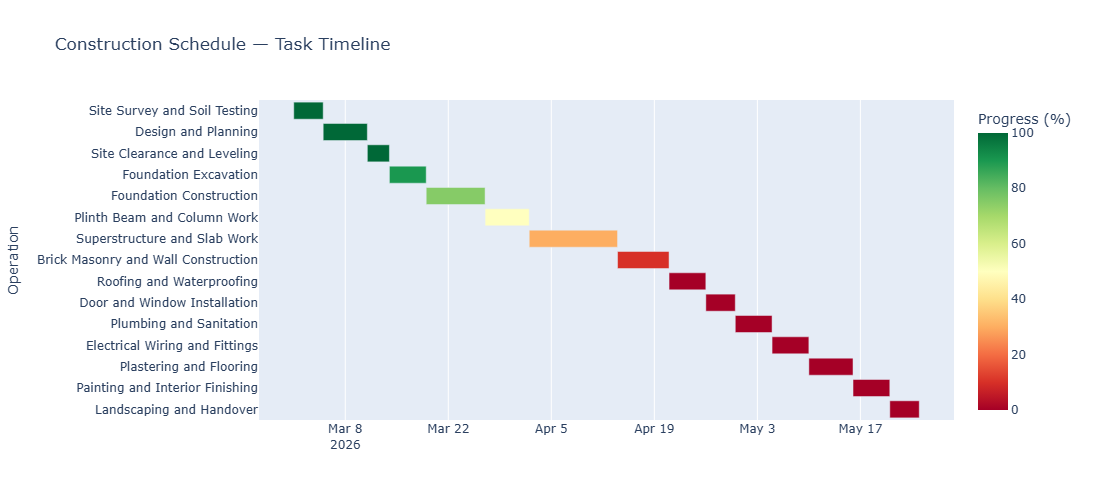

In [5]:
display(HTML("<h3 style='font-family:sans-serif; color:#333; margin:20px 0 10px;'>📅 Project Gantt Chart</h3>"))

fig_gantt = px.timeline(
    data,
    x_start="Start",
    x_end="End",
    y="Operation",
    color="Progress",
    color_continuous_scale="RdYlGn",
    range_color=[0, 100],
    title="Construction Schedule — Task Timeline",
    labels={"Progress": "Progress (%)"},
)
fig_gantt.update_yaxes(autorange="reversed")
fig_gantt.update_layout(xaxis_type="date", height=500)
fig_gantt.show()

## Cell 6 — Progress Bar Chart

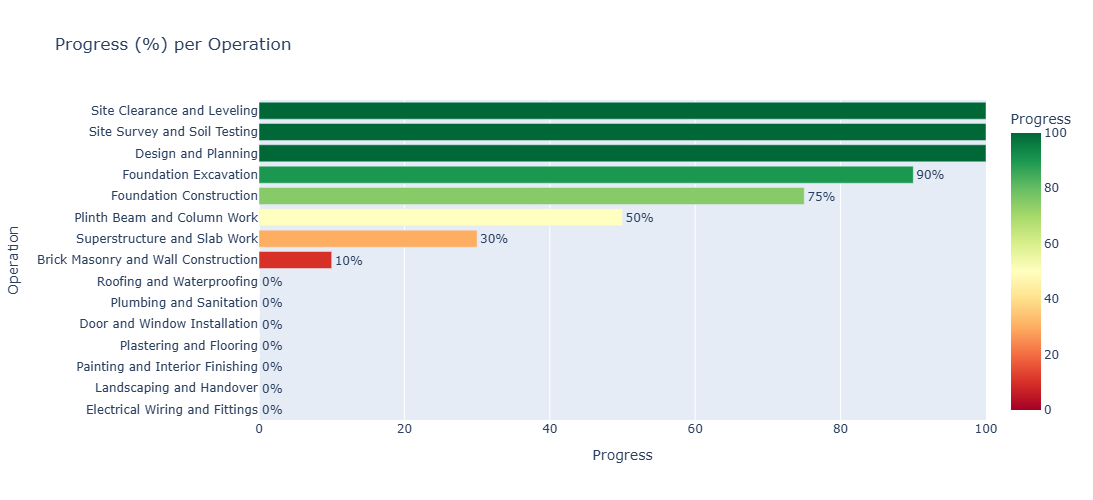

In [6]:
display(HTML("<h3 style='font-family:sans-serif; color:#333; margin:20px 0 10px;'>📈 Task-wise Progress</h3>"))

fig_bar = px.bar(
    data.sort_values("Progress"),
    x="Progress",
    y="Operation",
    orientation="h",
    color="Progress",
    color_continuous_scale="RdYlGn",
    range_color=[0, 100],
    range_x=[0, 100],
    text="Progress",
    title="Progress (%) per Operation"
)
fig_bar.update_traces(texttemplate="%{text:.0f}%", textposition="outside")
fig_bar.update_layout(height=500, showlegend=False)
fig_bar.show()

## Cell 7 — Gauge Chart

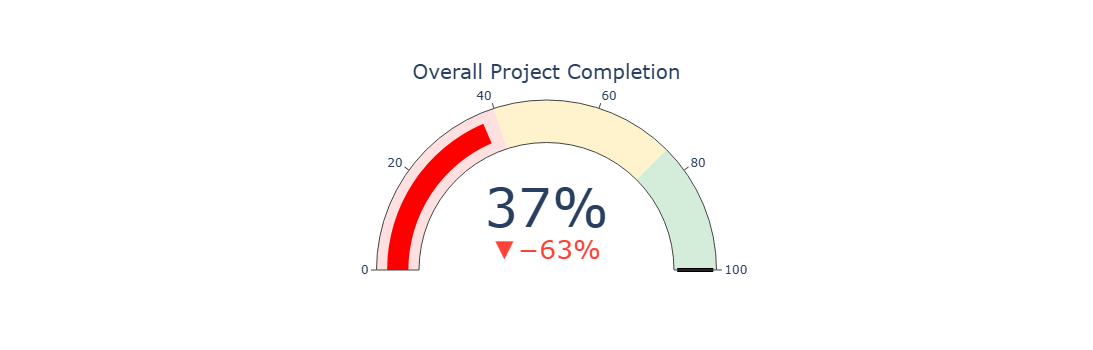

In [7]:
display(HTML("<h3 style='font-family:sans-serif; color:#333; margin:20px 0 10px;'>🎯 Overall Completion Gauge</h3>"))

fig_gauge = go.Figure(go.Indicator(
    mode="gauge+number+delta",
    value=overall_progress,
    delta={"reference": 100, "suffix": "%"},
    number={"suffix": "%"},
    gauge={
        "axis": {"range": [0, 100]},
        "bar": {"color": "green" if overall_progress >= 75 else "orange" if overall_progress >= 40 else "red"},
        "steps": [
            {"range": [0,  40],  "color": "#ffe0e0"},
            {"range": [40, 75],  "color": "#fff3cd"},
            {"range": [75, 100], "color": "#d4edda"},
        ],
        "threshold": {"line": {"color": "black", "width": 4}, "value": 100}
    },
    title={"text": "Overall Project Completion"}
))
fig_gauge.update_layout(height=350)
fig_gauge.show()

## Cell 8 — Console Summary

In [9]:
print("=" * 55)
print(f"  Overall Project Progress : {overall_progress:.2f}%")
print(f"  Total Tasks              : {len(data)}")
print(f"  Completed                : {int((data['Progress']==100).sum())}")
print(f"  Delayed                  : {int(data['Delay'].sum())}")
print("=" * 55)
print(f"\n{'Operation':<35} {'Progress':>9}  {'Status'}")
print("-" * 55)
for _, row in data.iterrows():
    status = "⚠️ Delayed" if row["Delay"] else "✅ On Track"
    print(f"  {row['Operation']:<33} {row['Progress']:>7.0f}%   {status}")
print("=" * 55)

  Overall Project Progress : 37.00%
  Total Tasks              : 15
  Completed                : 3
  Delayed                  : 0

Operation                            Progress  Status
-------------------------------------------------------
  Site Survey and Soil Testing          100%   ✅ On Track
  Design and Planning                   100%   ✅ On Track
  Site Clearance and Leveling           100%   ✅ On Track
  Foundation Excavation                  90%   ✅ On Track
  Foundation Construction                75%   ✅ On Track
  Plinth Beam and Column Work            50%   ✅ On Track
  Superstructure and Slab Work           30%   ✅ On Track
  Brick Masonry and Wall Construction      10%   ✅ On Track
  Roofing and Waterproofing               0%   ✅ On Track
  Door and Window Installation            0%   ✅ On Track
  Plumbing and Sanitation                 0%   ✅ On Track
  Electrical Wiring and Fittings          0%   ✅ On Track
  Plastering and Flooring                 0%   ✅ On Track
  P